## Модель предсказания вероятности клика (CTR) на рекламу

## Постановка задачи и требования

### Задача:
- построить модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление.

### Требования:

Калибровка:
- предсказанные вероятности кликов должны максимально точно соответствовать и их реальной частоте 

Метрики:
- PR-AUC — основная метрика. Она наиболее адекватно оценивает качество модели на несбалансированных данных. Клики — это более редкое событие, чем пропуск рекламы
- Log Loss позволит оценить точность предсказанных вероятностей. 
- Оценка Бриера измеряет и точность, и калибровку модели



## 1. Подготовка среды и загрузка данных

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from category_encoders import CountEncoder
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc, precision_recall_fscore_support
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score
import joblib


In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# загрузка данных
df = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

In [4]:
df.shape

(50000, 34)

In [5]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

## 2. Исследовательский анализ данных (EDA)

### 2.1 Базовая информация 

In [7]:
df.shape

(50000, 34)

In [8]:
df.isna().sum().sum()  # явных пропусков нет

np.int64(0)

In [9]:
cat_cols = df.select_dtypes(include=['object', 'str']).columns
num_cols = df.select_dtypes(include=['int64', 'float']).columns
cat_cols, len(cat_cols), num_cols, len(num_cols)

(Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
        'app_category', 'device_id', 'device_ip', 'device_model',
        'ml_feature_2', 'ml_feature_7'],
       dtype='str'),
 11,
 Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type',
        'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20',
        'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
        'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'],
       dtype='str'),
 23)

#### Датасет:

- 50000 объектов
- 33 признака и целевая переменная 
- 11 категориальных и 22 числовых признака, целевая переменная в виде числа
- данные не содержат явных пропусков

#### Пользователи и реклама:

Идентификаторы и временные метки:
- id — уникальный идентификатор записи о показе баннера;
- hour — час, в который был показан баннер, в формате YYMMDDHH.

Характеристики рекламной площадки ( Site ):
- site_id — идентификатор веб-сайта, на котором был показан баннер;
- site_domain — домен веб-сайта;
- site_category — тематическая категория веб-сайта.

Характеристики рекламируемого приложения ( App ):
- app_id — идентификатор рекламируемого мобильного приложения;
- app_domain — домен рекламируемого приложения;
- app_category — категория рекламируемого приложения.

Характеристики устройства и соединения пользователя:
- device_id — идентификатор браузера или устройства;
- device_ip — IP-адрес устройства;
- device_model — модель устройства;
- device_type — тип устройства пользователя: например, смартфон, планшет, ПК;
- device_conn_type — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

Характеристики рекламного баннера и аукциона:
- C1 — анонимизированный признак, характеризующий контекст показа;
- banner_pos — позиция баннера на веб-странице;
- C14 — C21 — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

Машинно-сгенерированные признаки (ML Features):
- ml_feature_1, ml_feature_3 — ml_feature_6, ml_feature_8 — ml_feature_10 — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- ml_feature_2, ml_feature_7 — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

Целевая переменная:
- click — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.



---

### 2.2 Анализ целевой переменной

In [10]:
target = df['click']

In [11]:
# Соотношение классов
target.value_counts() / len(target) * 100

click
0    82.794
1    17.206
Name: count, dtype: float64

Анализ:
- среди классов наблюдается дисбаланс: 83% пропусков рекламы, 17% кликов

Рекомендация:
- при разделениий на выброки необходимо применять стратификацию

---

### 2.3 Анализ признаков

#### Категориальные признаки

In [12]:
df[cat_cols].nunique()

site_id           1160
site_domain       1013
site_category       18
app_id             976
app_domain          67
app_category        22
device_id         8580
device_ip        41455
device_model      2521
ml_feature_2         5
ml_feature_7         3
dtype: int64

Анализ:
- уникальных значений для site_id, site_domain, app_id, device_id, device_ip, device_model довольно много (>900). Среди этих признаков имеются техническими данные, связянными со сбором информации. Кандиданты на удаление.
- проведем визуальных анализ распределения целевого класса среди категориальных признаков, где уникальных значений немного (<100).

#### Соотношение целевых классов внутри признаков

In [13]:
# для категориальных признаков cat_cols строим столбчатые диаграммы

def plot_bar_target_class(df: pd.DataFrame, target_name: str, cat_col: str):

    df_chain_unstack = df.groupby(cat_col)[target_name].value_counts(normalize=True).unstack(fill_value=0).sort_values(by=1)

    df_chain_unstack.plot(kind='bar', figsize=(10, 6),)

    plt.title(f'Доля целевых классов для признака {cat_col}') 
    plt.ylabel('Доля') 
    plt.xlabel(cat_col) 
    plt.xticks(rotation=45)  
    plt.legend()  

    plt.show()

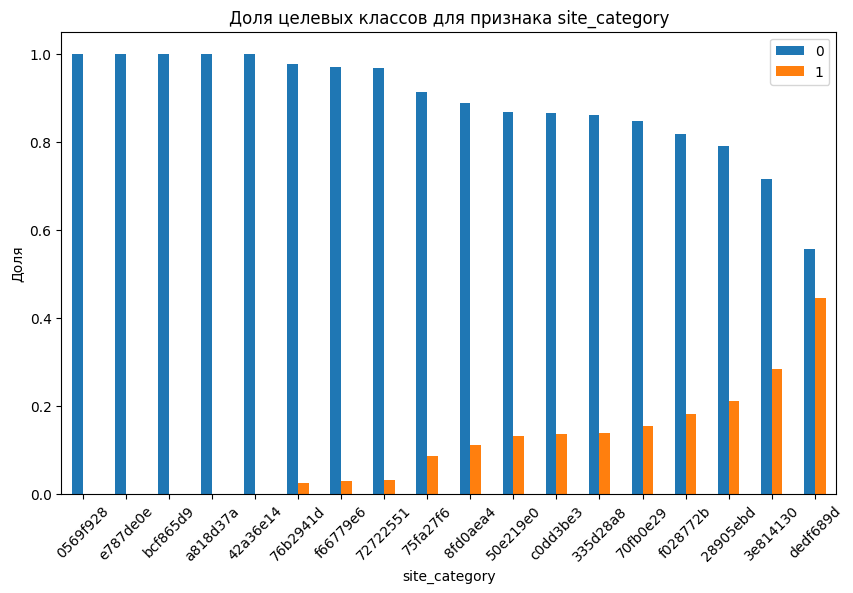

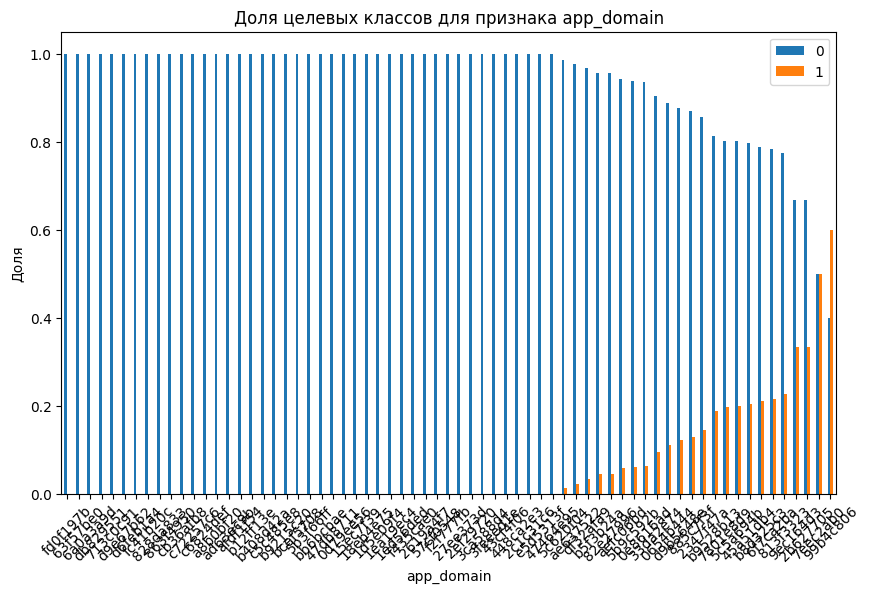

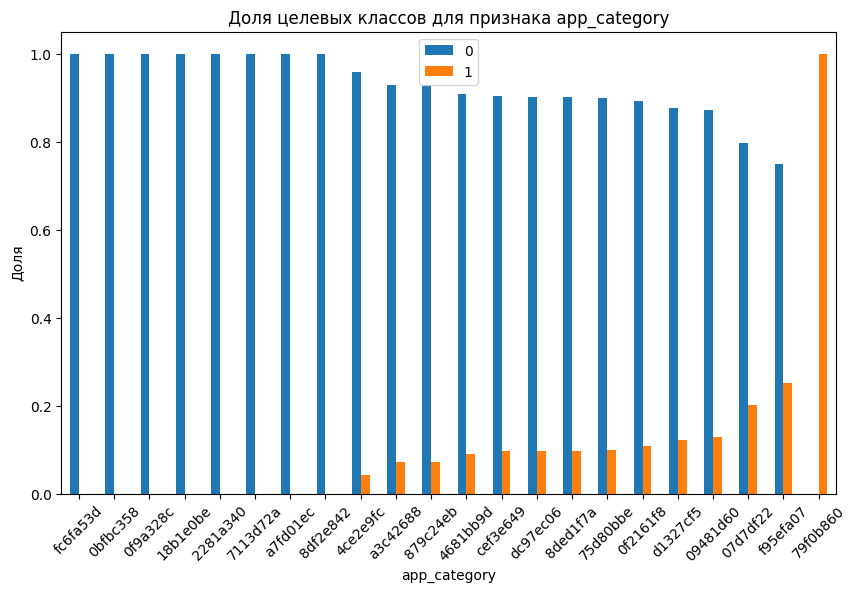

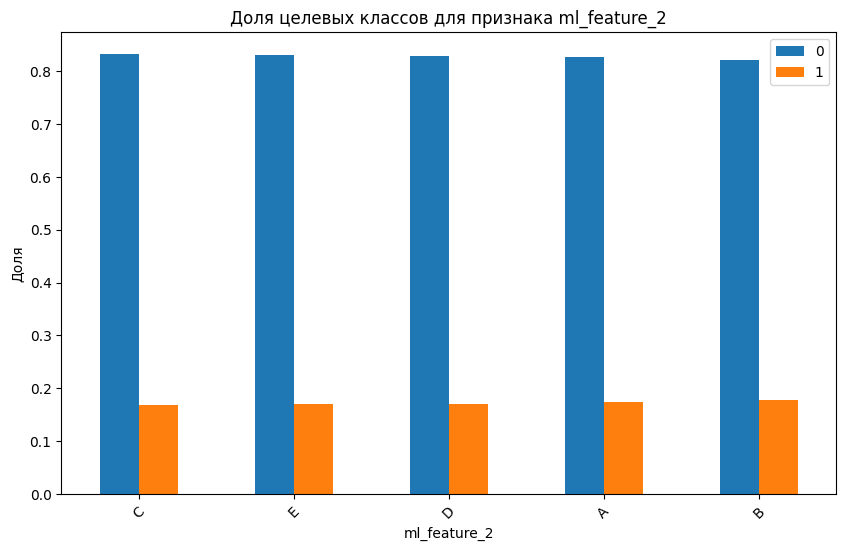

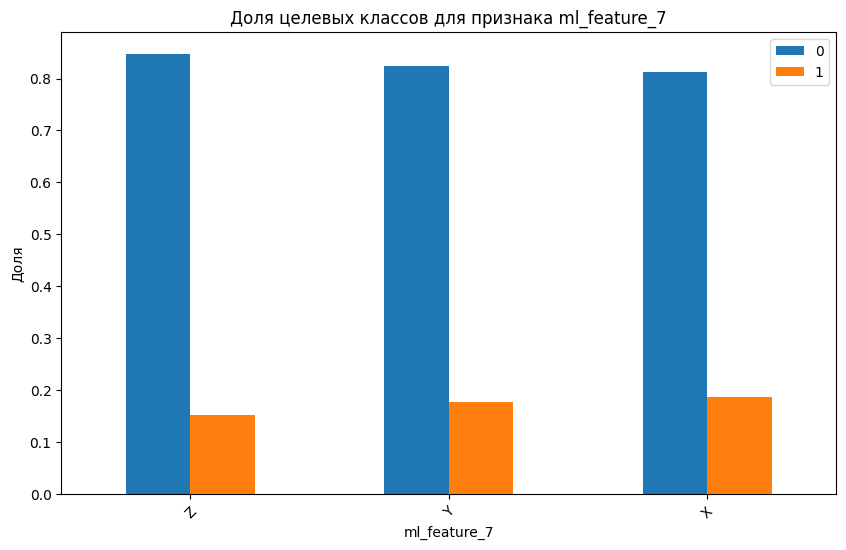

In [14]:
cat_cols_to_analyze = ['site_category', 'app_domain', 'app_category', 'ml_feature_2', 'ml_feature_7']
for name in cat_cols_to_analyze:
    plot_bar_target_class(df=df, target_name='click', cat_col=name)

Анализ:
- доля целевых классов внутри признаков ml_feature_7, ml_feature_2 практически не отличается
- для признаков 'site_category', 'app_domain', 'app_category' есть существенные различия по долям целевого класса

Рекомендация:
- ml_feature_7, ml_feature_2 - кандидаты на удаление, поскольку их связь с целевой переменной минимальна

In [15]:
cat_cols

Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
       'app_category', 'device_id', 'device_ip', 'device_model',
       'ml_feature_2', 'ml_feature_7'],
      dtype='str')

In [16]:
def get_target_corr(
        data: pd.DataFrame, feat_cols: list[str], 
        num_cols: list[str], target_col_name: str, 
        plot_corr_matrix: bool = True
):
    corr_matrix = data[feat_cols].phik_matrix(interval_cols=num_cols if len(num_cols) > 0 else None)

    if plot_corr_matrix:
        plt.figure(figsize=(14, 10)) 

        sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

        plt.title('Тепловая карта матрицы корреляций')
        plt.show()
    return corr_matrix[target_col_name].sort_values(ascending=False)

interval columns not set, guessing: ['click']


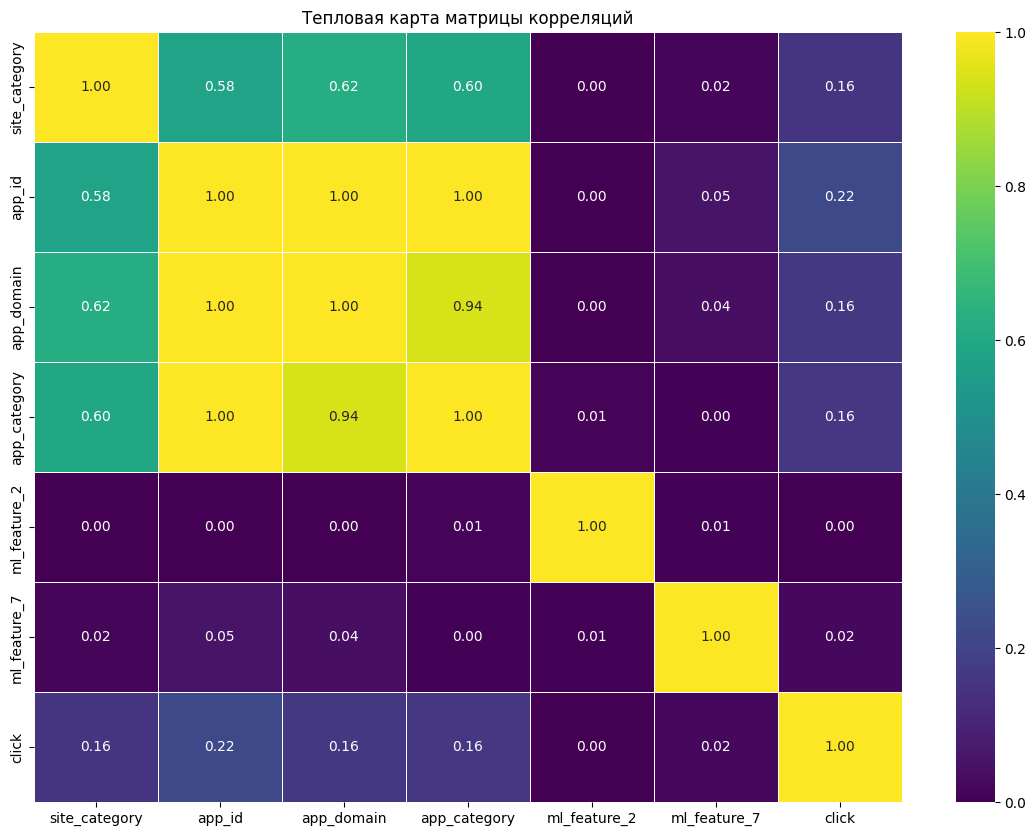

click            1.000000
app_id           0.221436
app_domain       0.161289
app_category     0.156537
site_category    0.155008
ml_feature_7     0.022622
ml_feature_2     0.003790
Name: click, dtype: float64

In [17]:
# Посчитаем матрицу корреляций для категорий, где количество уникальных значений позволяет это сделать
cols_to_show = ['site_category', 'app_id', 'app_domain','app_category','ml_feature_2', 'ml_feature_7', 'click']

corr_with_target_cat = get_target_corr(df, cols_to_show, [], target_col_name='click')
corr_with_target_cat

Анализ:
- высокая корреляция (от 0.94 и до 1) между признаками: app_id, app_domain, app_category. Для избежания проблемы мультиколлинеарности стоит оставить только один из них. Можно оставить наиболее скоррелированный с целевой переменной
-  наиболее связан с click признак app_id: 0.221436
- наименее связанные признаки с click: 
    - ml_feature_7:     0.022622
    - ml_feature_2:     0.003790

#### Кодирование категориальных признаков

- признаки, для которых уникальных значений <10 будем кодировать OneHotEncoder
- признаки с большим кол-вом уникальных значений будем кодировать с помощью TargetEncoding, чтобы не раздувать размерность задачи

In [18]:
cat_nunique = df[cat_cols].nunique()
one_hot_code_cols = cat_nunique[cat_nunique < 10]

print('кандидаты для кодирования OneHot: ')
one_hot_code_cols

кандидаты для кодирования OneHot: 


ml_feature_2    5
ml_feature_7    3
dtype: int64

In [19]:
target_code_cols = cat_nunique[cat_nunique > 10]

print('кандидаты для кодирования TargetEncoder: ')
target_code_cols

кандидаты для кодирования TargetEncoder: 


site_id           1160
site_domain       1013
site_category       18
app_id             976
app_domain          67
app_category        22
device_id         8580
device_ip        41455
device_model      2521
dtype: int64

---
#### Количественные признаки

In [20]:
df[num_cols].head()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,1,0,17614,320,50,...,-1,33,-0.996823,0.666588,0,0.817292,0.993275,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1,0,15701,320,50,...,-1,79,-0.391309,5.146789,1,-0.883865,-0.825722,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,1,0,17914,320,50,...,100084,32,-2.112732,7.169348,0,-0.859440,-0.338365,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,1,0,21611,320,50,...,100111,61,0.332707,-0.290708,1,0.062795,0.062934,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1,0,15702,320,50,...,100084,79,1.166623,6.319134,1,-0.675276,0.797144,0.640827,0.297955,-0.136909


- данные содержат признак hours в формате YYMMDDHH и типа int. Этот признак стоит преобразовать

#### Преобразование признака hours

In [21]:
# преобразуем hour в формат даты
hour_str = df['hour'].astype(str).str.zfill(8)
dt_format = pd.to_datetime(hour_str, format="%y%m%d%H")

# 
df['hour_of_day'] = dt_format.dt.hour
df['day'] = dt_format.dt.day
df['month'] = dt_format.dt.month
df['year'] = dt_format.dt.year

# циклические признаки (чтобы 23ч и 0ч воспринимались, как близкие значения)
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

df = df.drop(columns=['hour'])

In [22]:
df.head()

,id,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
0,1.005263e+19,1,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,Z,-0.619959,0.433666,0.274038,0,21,10,2014,0.0,1.0
1,1.010597e+19,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,X,0.576526,-0.318558,-0.132851,0,21,10,2014,0.0,1.0
2,1.012048e+19,0,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,Y,-0.440047,-0.345412,0.340487,0,21,10,2014,0.0,1.0
3,1.021995e+18,0,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,...,Y,0.551982,0.733382,-0.198542,0,21,10,2014,0.0,1.0
4,1.023455e+19,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,X,0.640827,0.297955,-0.136909,0,21,10,2014,0.0,1.0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   C1                50000 non-null  int64  
 3   banner_pos        50000 non-null  int64  
 4   site_id           50000 non-null  str    
 5   site_domain       50000 non-null  str    
 6   site_category     50000 non-null  str    
 7   app_id            50000 non-null  str    
 8   app_domain        50000 non-null  str    
 9   app_category      50000 non-null  str    
 10  device_id         50000 non-null  str    
 11  device_ip         50000 non-null  str    
 12  device_model      50000 non-null  str    
 13  device_type       50000 non-null  int64  
 14  device_conn_type  50000 non-null  int64  
 15  C14               50000 non-null  int64  
 16  C15               50000 non-null  int64  
 17  C16 

In [24]:
# обновляем значение категиальных и числовых признаков
cat_cols = df.select_dtypes(include=['object', 'str']).columns
num_cols = df.select_dtypes(include=['int', 'float']).columns
cat_cols, len(cat_cols), num_cols, len(num_cols)

(Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
        'app_category', 'device_id', 'device_ip', 'device_model',
        'ml_feature_2', 'ml_feature_7'],
       dtype='str'),
 11,
 Index(['id', 'click', 'C1', 'banner_pos', 'device_type', 'device_conn_type',
        'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1',
        'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6',
        'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour_of_day', 'day',
        'month', 'year', 'hour_sin', 'hour_cos'],
       dtype='str'),
 28)

In [25]:
df[num_cols].describe()

,id,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,...,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,5.000000e+04,50000.000000
mean,9.215402e+18,0.172060,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,2109.781020,...,0.022948,0.025465,0.035361,0.020226,11.221500,25.478220,10.0,2014.0,4.729782e-02,-0.198552
std,5.328516e+18,0.377436,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,612.963141,...,0.656690,0.578026,0.505034,0.303309,5.938008,2.964945,0.0,0.0,7.194056e-01,0.663939
min,3.191077e+13,0.000000,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,112.000000,...,-1.000000,-0.999965,-2.147526,-1.287965,0.000000,21.000000,10.0,2014.0,-1.000000e+00,-1.000000
25%,4.580649e+18,0.000000,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,1823.000000,...,-0.579775,-0.470627,-0.304077,-0.182386,6.000000,23.000000,10.0,2014.0,-7.071068e-01,-0.866025
50%,9.243015e+18,0.000000,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,2323.000000,...,0.037786,0.027348,0.035985,0.018930,11.000000,26.000000,10.0,2014.0,1.224647e-16,-0.258819
75%,1.380920e+19,0.000000,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,2526.000000,...,0.637131,0.521117,0.374152,0.224080,16.000000,28.000000,10.0,2014.0,7.071068e-01,0.500000
max,1.844652e+19,1.000000,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,2757.000000,...,1.000000,1.119858,2.120786,1.202300,23.000000,30.000000,10.0,2014.0,1.000000e+00,1.000000


#### корреляционный анализ

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.13/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable month for analysis 1. Dropping this column
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.13/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable year for analysis 1. Dropping this column
  warnings.warn(


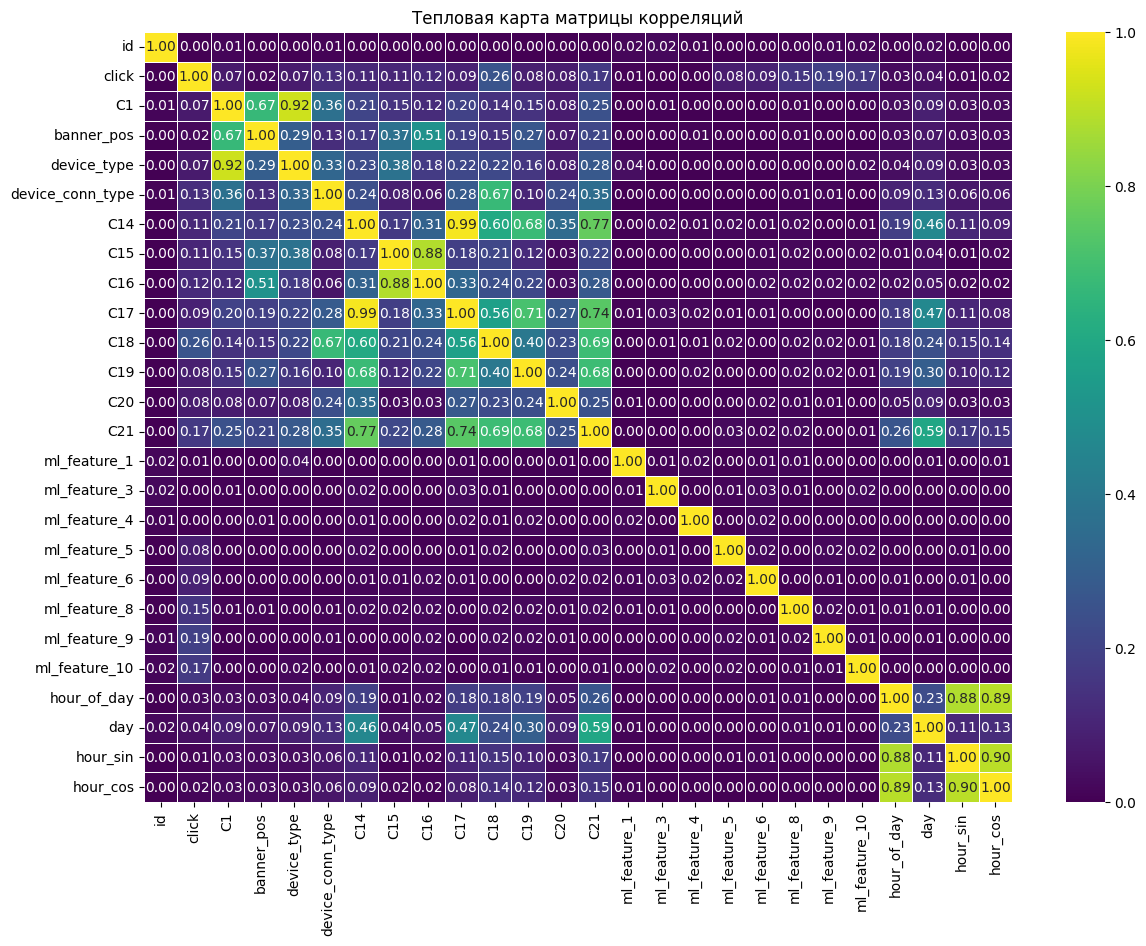

In [26]:
corr_with_target_num = get_target_corr(df, num_cols, num_cols, target_col_name='click')


In [27]:
top_n = 10

print(f'Топ {top_n} по корреляции с целевой переменной:')
corr_with_target_num[:top_n], corr_with_target_num[:top_n].index

Топ 10 по корреляции с целевой переменной:


(click               1.000000
 C18                 0.257840
 ml_feature_9        0.187801
 ml_feature_10       0.169983
 C21                 0.166235
 ml_feature_8        0.153598
 device_conn_type    0.129954
 C16                 0.117539
 C14                 0.112890
 C15                 0.106817
 Name: click, dtype: float64,
 Index(['click', 'C18', 'ml_feature_9', 'ml_feature_10', 'C21', 'ml_feature_8',
        'device_conn_type', 'C16', 'C14', 'C15'],
       dtype='str'))

In [28]:
last_n = 5

print(f'Наименее скореллированные с целевой переменной {last_n} признаков:')
corr_with_target_num[-last_n:], corr_with_target_num[-last_n:].index

Наименее скореллированные с целевой переменной 5 признаков:


(ml_feature_1    0.010056
 hour_sin        0.009241
 ml_feature_4    0.000000
 ml_feature_3    0.000000
 id              0.000000
 Name: click, dtype: float64,
 Index(['ml_feature_1', 'hour_sin', 'ml_feature_4', 'ml_feature_3', 'id'], dtype='str'))

Анализ:
- высокие коэффициенты корреляции:
    - C14, C17 -  0.99
    - C1, device_type - 0.92
    - C15, C16 - 0.88
    - hours_sin, hours_cos - 0.9

- наиболее скоррелированные признаки с целевой переменной (их точно стоит оставить): 
    - 'C18', 'ml_feature_9', 'ml_feature_10', 'C21', 'ml_feature_8',
        'device_conn_type', 'C16', 'C14', 'C15'
- наименее скорреированные с целевой переменной (кандидаты на удаление):
    - 'ml_feature_1', 'hour_sin', 'ml_feature_4', 'ml_feature_3', 'id'

Рекомендация:
- для избежания проблемы мультиколлинеарности стоит рассмотреть удаление одного признака из пары сильно скоррлированных 
- мало скоррелированные признаки с целевой переменной стоит рассмотреть к удалению
- после разбиение на train/test можно еще раз взглянуть на корреляции этих признаков и удалить высоко скоррелированные между собой

### Анализ распределений

In [29]:
df[num_cols].head()

,id,click,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,...,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
0,1.005263e+19,1,1005,1,1,0,17614,320,50,1993,...,0.993275,-0.619959,0.433666,0.274038,0,21,10,2014,0.0,1.0
1,1.010597e+19,0,1005,0,1,0,15701,320,50,1722,...,-0.825722,0.576526,-0.318558,-0.132851,0,21,10,2014,0.0,1.0
2,1.012048e+19,0,1005,0,1,0,17914,320,50,2043,...,-0.338365,-0.440047,-0.345412,0.340487,0,21,10,2014,0.0,1.0
3,1.021995e+18,0,1005,0,1,0,21611,320,50,2480,...,0.062934,0.551982,0.733382,-0.198542,0,21,10,2014,0.0,1.0
4,1.023455e+19,0,1005,0,1,0,15702,320,50,1722,...,0.797144,0.640827,0.297955,-0.136909,0,21,10,2014,0.0,1.0


In [30]:
def boxplot_describe(
    feature_names_list: list[str], df: pd.DataFrame=df, 
    fig_sz: tuple[int, int] = (12, 5), target='click', density=True
):
    n_features = len(feature_names_list)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_sz[0], fig_sz[1] * n_rows))
    axes = axes.flatten() 

    idx_1 = np.where(df[target] == 1)
    idx_0 = np.where(df[target] == 0)
    for i, feature in enumerate(feature_names_list):
        ax = axes[i]
        data = df[feature]

        data_1 = data.iloc[idx_1]
        data_0 = data.iloc[idx_0]

        ax.hist(data_0, density=density, alpha=0.5, label=f'{target} = 0', bins=30)
        ax.hist(data_1, density=density, alpha=0.5, label=f'{target} = 1', bins=30)

        ax.set_title(f'Распределение признака {feature} по классам {target}')
        ax.set_xlabel(feature)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

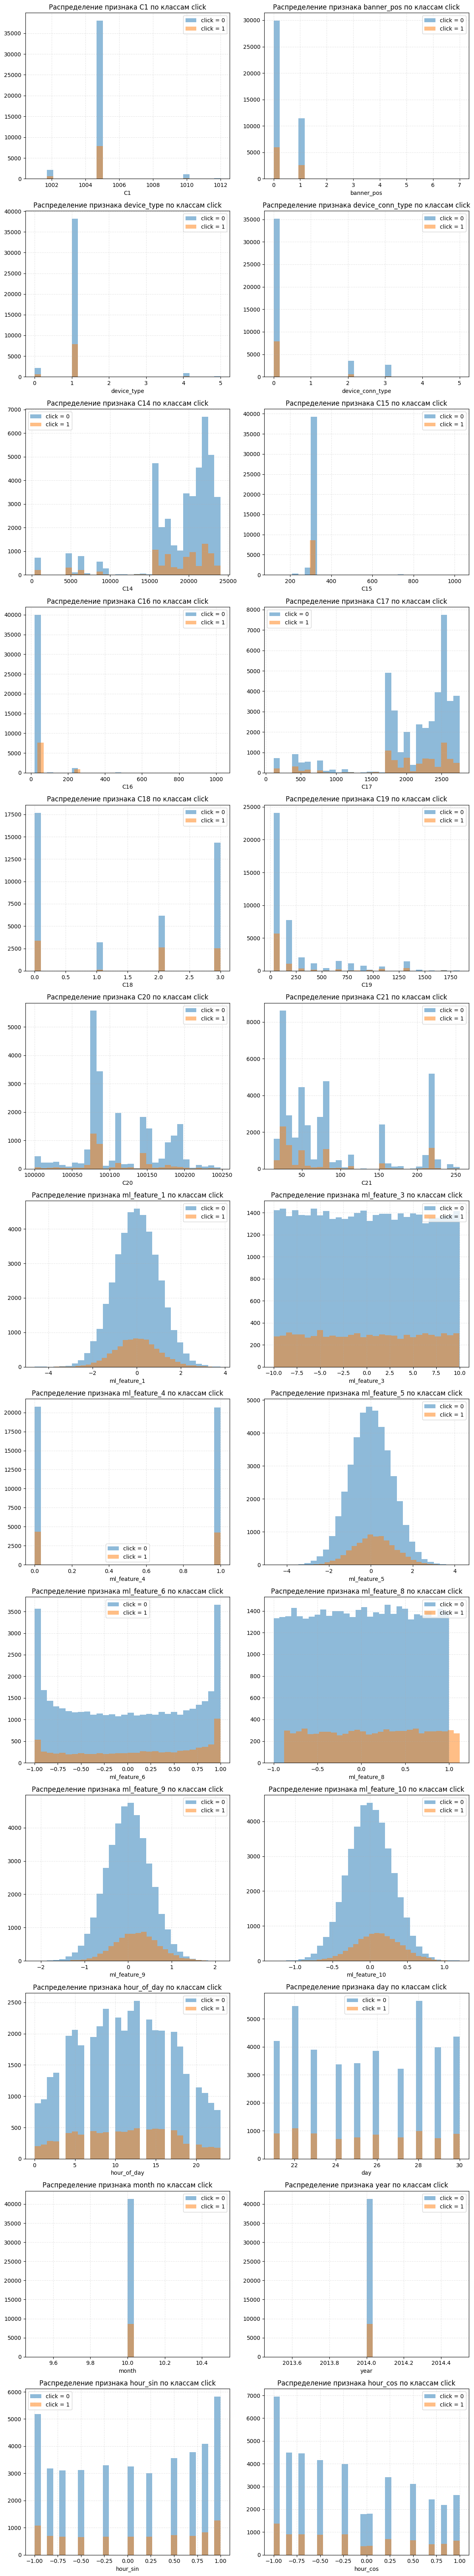

In [215]:

boxplot_describe(feature_names_list=num_cols[2:], df=df, density=False)

Анализ:
- распределение признаков ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 можно приблизить нормальным, имеет смысл применить z-score фильтрацию и отсечь хвосты распределений 
- необходимо провести дополнительный анализ количественных признаков с дискретным набором значений

#### Количественные признаки с дискретным набором значений

In [32]:
num_cols_special = [
    'banner_pos', 'device_type', 'device_conn_type', 
    'C1', 'C15', 'C16', 'C18', 'C20', 'ml_feature_4',
    'month', 'year'
]

In [33]:
df[num_cols_special].describe()

,banner_pos,device_type,device_conn_type,C1,C15,C16,C18,C20,ml_feature_4,month,year
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0
mean,0.291380,1.018120,0.337160,1004.970060,318.86640,59.692480,1.428100,53173.383240,0.498040,10.0,2014.0
std,0.514201,0.538477,0.860057,1.110202,20.56153,46.720842,1.327413,49960.181871,0.500001,0.0,0.0
min,0.000000,0.000000,0.000000,1001.000000,120.00000,20.000000,0.000000,-1.000000,0.000000,10.0,2014.0
25%,0.000000,1.000000,0.000000,1005.000000,320.00000,50.000000,0.000000,-1.000000,0.000000,10.0,2014.0
50%,0.000000,1.000000,0.000000,1005.000000,320.00000,50.000000,2.000000,100049.000000,0.000000,10.0,2014.0
75%,1.000000,1.000000,0.000000,1005.000000,320.00000,50.000000,3.000000,100094.000000,1.000000,10.0,2014.0
max,7.000000,5.000000,5.000000,1012.000000,1024.00000,1024.000000,3.000000,100248.000000,1.000000,10.0,2014.0


In [34]:
df['C20'].value_counts() / len(df['C20']) * 100

C20
-1         46.886
 100084     6.018
 100148     4.442
 100111     4.220
 100077     3.916
            ...  
 100224     0.004
 100213     0.004
 100024     0.002
 100229     0.002
 100178     0.002
Name: count, Length: 149, dtype: float64

Неявные пропуски:
- для признака C20 значения -1 скорее всего являются обозначением пропусков
- количество пропусков 46.9%, что довольно существенно. Удалять не будем, заменим на статистику распределения - медиану (после разбиения на train/test)
- на данный момент необходимо сделать эти припуски явными и заменить на Nan

Выбросы:
-  С15, С16 имеют выбросы (максимальное значение на порядок отличается от 75 перцентиля)
- можно рассмотреть замену этих значений на моду 

In [35]:
df['C20'] = df['C20'].replace(-1, np.nan) # теперь пропуски явные

### 2.4 Фильтрация признаков

Фильтрация явно бесполезных признаков: идентификаторы пользователей, сайтов, устройств, домены сайтов, ip адреса и модели устройств пользователей:
- id, site_id, site_domain, device_id, device_ip, device_model

Остальные признаки потенциально полезны для анализа

In [36]:
df = df.drop(columns=['id', 'site_id', 'site_domain', 'device_id', 'device_ip', 'device_model'])
df.head()

,click,C1,banner_pos,site_category,app_id,app_domain,app_category,device_type,device_conn_type,C14,...,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10,hour_of_day,day,month,year,hour_sin,hour_cos
0,1,1005,1,f028772b,ecad2386,7801e8d9,07d7df22,1,0,17614,...,Z,-0.619959,0.433666,0.274038,0,21,10,2014,0.0,1.0
1,0,1005,0,28905ebd,ecad2386,7801e8d9,07d7df22,1,0,15701,...,X,0.576526,-0.318558,-0.132851,0,21,10,2014,0.0,1.0
2,0,1005,0,f028772b,ecad2386,7801e8d9,07d7df22,1,0,17914,...,Y,-0.440047,-0.345412,0.340487,0,21,10,2014,0.0,1.0
3,0,1005,0,50e219e0,39cfef32,d9b5648e,0f2161f8,1,0,21611,...,Y,0.551982,0.733382,-0.198542,0,21,10,2014,0.0,1.0
4,0,1005,0,28905ebd,ecad2386,7801e8d9,07d7df22,1,0,15702,...,X,0.640827,0.297955,-0.136909,0,21,10,2014,0.0,1.0


#### Анализ квази-константных признаков

In [37]:
def get_quasi_constant_features(
    df: pd.DataFrame,
    num_threshold: float = 0.0,
    cat_threshold: float = 1.0,
) -> list[str]:
    quasi_num_cols = []
    quasi_cat_cols = []

    # Числовые признаки
    numerical_columns = df.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    if numerical_columns:
        numerical_data = df[numerical_columns]

        vs_quasi = VarianceThreshold(threshold=num_threshold)
        vs_quasi.fit(numerical_data)
        quasi_num_cols = [
            col for col, keep in zip(numerical_columns, vs_quasi.get_support()) if not keep
        ]

    # Категориальные признаки
    categorical_columns = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    for col in categorical_columns:
        freqs = df[col].value_counts(normalize=True, dropna=False)
        if not freqs.empty and freqs.iloc[0] >= cat_threshold:
            quasi_cat_cols.append(col)

    quasi_constant_cols = quasi_num_cols + quasi_cat_cols
    return quasi_constant_cols



In [38]:
get_quasi_constant_features(df, num_threshold=0., cat_threshold=1.0)

['month', 'year']

In [39]:
get_quasi_constant_features(df, num_threshold=0.1, cat_threshold=.9)

['ml_feature_10', 'month', 'year']

Анализ:

- константные признаки: 'month', 'year' (можно удалять, пользы в них нет) 
- Среди квази-константных можно выделить ml_feature_10 с дисперсией менее 0.1. Пока решение об удалении не принимаем. Распределение по значениям не выгдядит, как костантное. Помимо этого, признак имеет корреляцию с целевой переменной на уровне 0.19 (в теории может быть полезен)

### 2.5 Итог:

1. Базовая инфомация:
    - 50000 объектов
    - 33 признака и целевая переменная 
    - 11 категориальных и 22 числовых признака, целевая переменная в виде числа
    - данные не содержат явных пропусков

2. Целевая переменная:
    - среди классов наблюдается дисбаланс: 83% пропусков рекламы, 17% кликов
    - при разделениий на выброки необходимо применять стратификацию

3. Анализ признаков.

    a) Категориальные признаки:
    - признаки site_id, site_domain, app_id, device_id, device_ip, device_model содержат большое количество уникальных значений. Присутствует техническая информация, связанная с процессом сбора данных. Кандидаты на удаление.
    - категориальные признаки с большим количеством уникальных значений (>10) рекомендовано кодировать с помощью **TargetEncoder** (site_category, app_id, app_domain, app_category), чтобы не рездувать признаковое пространство. Остальные кодируем с помощью **OneHot** (ml_feature_2, ml_feature_7)
    - доля целевых классов внутри признаков ml_feature_7, ml_feature_2 практически не отличается. Кандидаты на удаление.
    - высокая корреляция (от 0.94 и до 1) между признаками: app_id, app_domain, app_category. Для избежания проблемы мультиколлинеарности стоит оставить только один из них. Можно оставить наиболее скоррелированный с целевой переменной
    - наиболее связан с click признак app_id: 0.221436
    - наименее связанные признаки с click (кандидаты на удаление): 
        - ml_feature_7:     0.022622
        - ml_feature_2:     0.003790
    
    b) Количественные признаки:

   - высокие коэффициенты корреляции:
    - C14, C17 -  0.99
    - C1, device_type - 0.92
    - C15, C16 - 0.88
    - hours_sin, hours_cos - 0.9

    - наиболее скоррелированные признаки с целевой переменной (их точно стоит оставить): 
        - 'C18', 'ml_feature_9', 'ml_feature_10', 'C21', 'ml_feature_8',
            'device_conn_type', 'C16', 'C14', 'C15'
    - наименее скорреированные с целевой переменной (кандидаты на удаление):
        - 'ml_feature_1', 'hour_sin', 'ml_feature_4', 'ml_feature_3', 'id'
    - Распределения с выбросами:
        - распределение признаков ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 по виду близкое к нормальному, имеет смысл применить z-score фильтрацию и отсечь хвосты распределений 
        -  С15, С16  имеют выбросы. Стоит применить фильтрацию с заменой выбросов на моду
        - после разделения на train/test стоит провести z-score фильтрацию по 3 сигма для количественных данных, чтобы отсеять выбросы в распределениях

4. Фильтрация.

- По результатам анализа выявлены признаки, бесполезные для дальнейшего анализа. Среди них: идентификаторы пользователей, сайтов, устройств, домены сайтов, ip адреса и модели устройств пользователей.
- id, site_id, site_domain, device_id, device_ip, device_model
- Указанные признаки были удалены.

6. Преобразование признаков
- признак hour был преобразован из int формата YYMMDDHH в формат дат: year, month, day, hour_of_day
- для учета цикличности были добавлены признаки: hour_cos, hour_sin
- признак hour был удален

7. Неявные пропуски:
- найдены неявные пропуски в C20: значения -1. Для последующей корректной обработки флаги были изменены на np.nan

8. Константные и квази-константные признаки
- сгенерированные признаки year, month оказались константными и были удалены за ненадобностью
- признак ml_feature_10 определен алгоритмом как квази константный с порогом 0.1 по стандартному отклонению. Но, исходя из корреляционного анализа, он выглядит перспективным. Поэтому его не рекомендуется удалять на данном этапе

8. Наиболее перспективные признаки для модели:
-  app_id
- C18                
- ml_feature_9        
- ml_feature_10      
- C21                 
- ml_feature_8        
- device_conn_type    
- C16                 
- C14                 

6. Что нужно сделать в предобработке (на train):
- отмасштабировать все признаки 
- z-score фильтрацию по 3 сигма для ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10, чтобы отсеять выбросы в распределениях
- заменить пропуски в C20 на медианные значение 
- применить z-score фильтрацию с заменой на моду для С15, С16
- кодирование категориальных признаков: Target/OneHot
- провести еще раз корреляционный анализ и отсеять мало связанные с целевой переменной признаки (еще раз проверить кандидатов), отсеять сильно скоррелированные между собой признаки


## 3. Разделение данных на выборки

In [40]:
X = df.drop(columns=['click'])
y = df['click']

In [41]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)


X_calib, X_train, y_calib, y_train = train_test_split(
    X_train_full, y_train_full, test_size=0.8, random_state=RANDOM_SEED, stratify=y_train_full
)

In [42]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_calib.shape, y_calib.shape

((32000, 32), (10000, 32), (32000,), (10000,), (8000, 32), (8000,))

In [43]:
# Доля целевых классов в обучающей выборке
for name, data in zip(['train', 'test', 'calib'], [y_train, y_test, y_calib]):
    print(f'Доля классов в {name} выборке:')
    print(data.value_counts() / len(data) * 100)
    print('-'*30)


Доля классов в train выборке:
click
0    82.79375
1    17.20625
Name: count, dtype: float64
------------------------------
Доля классов в test выборке:
click
0    82.79
1    17.21
Name: count, dtype: float64
------------------------------
Доля классов в calib выборке:
click
0    82.8
1    17.2
Name: count, dtype: float64
------------------------------


- разбиение на train/calib/test прошло ожидаемо, стратификация корректна 

## 4. Фильтрация признаков

In [44]:
# числовые признаки
num_cols_tot = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols_tot

['C1',
 'banner_pos',
 'device_type',
 'device_conn_type',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'ml_feature_1',
 'ml_feature_3',
 'ml_feature_4',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_8',
 'ml_feature_9',
 'ml_feature_10',
 'hour_of_day',
 'day',
 'month',
 'year',
 'hour_sin',
 'hour_cos']

In [45]:
# категориальные признаки
cat_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
cat_cols

['site_category',
 'app_id',
 'app_domain',
 'app_category',
 'ml_feature_2',
 'ml_feature_7']

### 4.1 Фильтрация на основе корреляционного анализа признаков

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.13/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable month for analysis 1. Dropping this column
  warnings.warn(
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.13/site-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable year for analysis 1. Dropping this column
  warnings.warn(


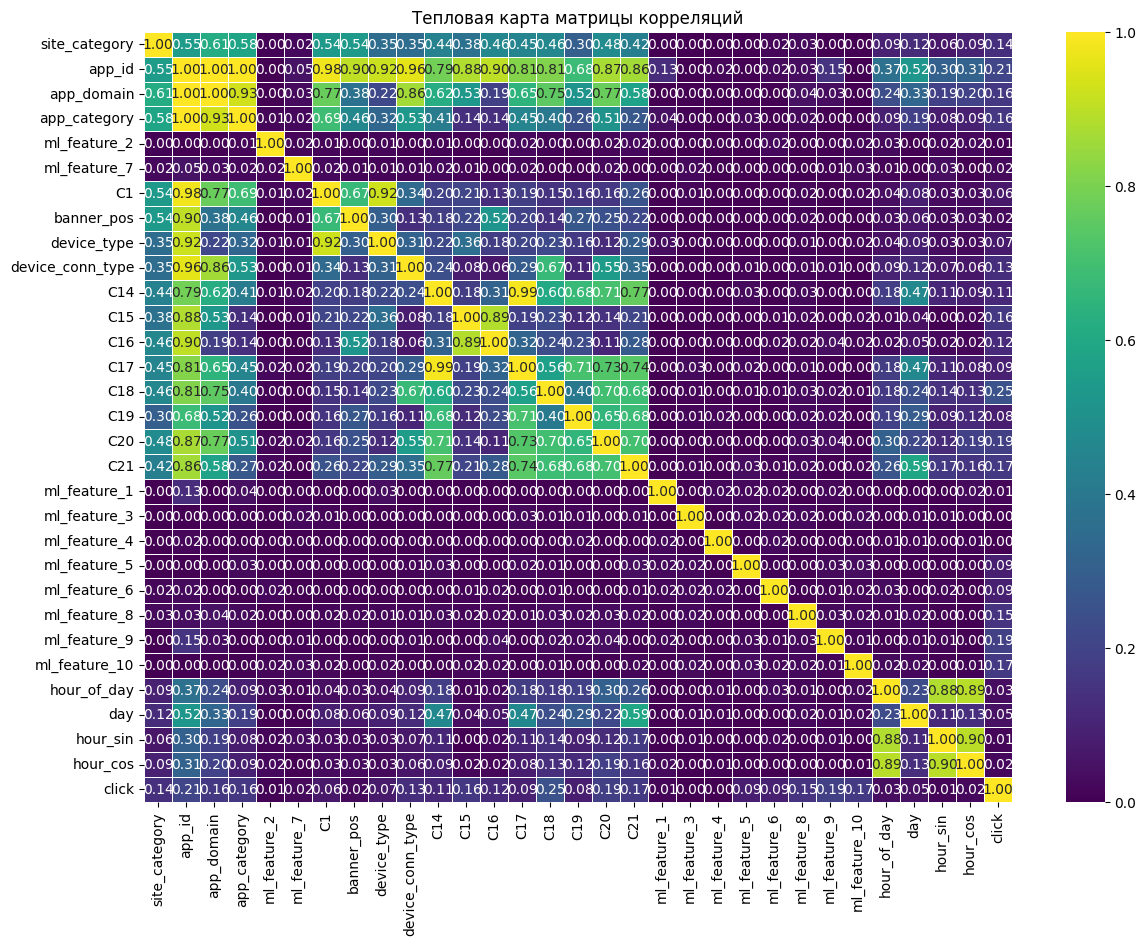

In [46]:
corr_with_target = get_target_corr(
    data=pd.concat([X_train, y_train], axis=1), 
    feat_cols=cat_cols + num_cols_tot + ['click'], 
    num_cols=num_cols_tot, 
    target_col_name='click'
    )

In [47]:
corr_with_target.head(15)

click               1.000000
C18                 0.251398
app_id              0.210240
ml_feature_9        0.193536
C20                 0.185807
ml_feature_10       0.167837
C21                 0.167125
C15                 0.163635
app_domain          0.160674
app_category        0.159276
ml_feature_8        0.149773
site_category       0.138173
device_conn_type    0.131811
C16                 0.117264
C14                 0.114317
Name: click, dtype: float64

In [48]:
# отбираем признаки с низкой корреляцией
threshold = 0.05
low_corr_features = corr_with_target[corr_with_target < threshold].index
low_corr_features

Index(['day', 'hour_of_day', 'ml_feature_7', 'banner_pos', 'hour_cos',
       'hour_sin', 'ml_feature_1', 'ml_feature_2', 'ml_feature_3',
       'ml_feature_4'],
      dtype='str')

Чтобы уйти от мультиколлинеарности, необходимо удалить:
- app_domain, app_category, C1, device_conn_type - корреляция с app_id выше 0.95
- С17 коррелирует с C14: corr = 0.99. Убираем С17, поскольку менее скоррелирована с click
- корреляция между hour_sin, hour_cos, hours_of_day: >0.85. Убираем hour_sin и hour_cos, поскольку менее связаны с целевой переменной

получены название признаков, мало связанных с целевой переменной


In [49]:
сols_to_drop = ['app_domain', 'app_category', 'device_conn_type', 'C17', 'C1', 'hour_sin', 'hour_cos']
сols_to_drop += low_corr_features.to_list()
сols_to_drop = list(set(сols_to_drop))
сols_to_drop

['hour_of_day',
 'ml_feature_7',
 'ml_feature_4',
 'day',
 'banner_pos',
 'hour_sin',
 'C17',
 'C1',
 'app_domain',
 'ml_feature_1',
 'ml_feature_2',
 'device_conn_type',
 'ml_feature_3',
 'hour_cos',
 'app_category']

#### Фильтрация по вариации `VarianceThreshold`.

In [50]:
сols_to_drop_var = get_quasi_constant_features(df=X_train, num_threshold=0.05, cat_threshold=0.9)
сols_to_drop_var


['month', 'year']

In [51]:
сols_to_drop += сols_to_drop_var
сols_to_drop

['hour_of_day',
 'ml_feature_7',
 'ml_feature_4',
 'day',
 'banner_pos',
 'hour_sin',
 'C17',
 'C1',
 'app_domain',
 'ml_feature_1',
 'ml_feature_2',
 'device_conn_type',
 'ml_feature_3',
 'hour_cos',
 'app_category',
 'month',
 'year']

Итог:
- по результатам корреляционного анализа и анализа вариаций был получен список мало информативных переменых. 

## 5. Предобработка данных — построение пайплайнов

In [52]:
class ZScoreOutlierReplacer(BaseEstimator, TransformerMixin):
    """Класс фильтрации z-score"""
    def __init__(self, z_threshold: float = 3.0):
        self.z_threshold = z_threshold

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.means_ = np.nanmean(X, axis=0)
        self.stds_ = np.nanstd(X, axis=0)
        self.medians_ = np.nanmedian(X, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()

        safe_stds = np.where(self.stds_ == 0, 1, self.stds_)
        z = np.abs((X - self.means_) / safe_stds)

        outlier_mask = z > self.z_threshold
        X[outlier_mask] = np.take(self.medians_, np.where(outlier_mask)[1])
        return X

    def set_output(self, *, transform=None):
        self._transform_output = transform
        return self
    
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)



def replace_zscore_outliers_with_median(z_threshold: float = 3.0):
    return ZScoreOutlierReplacer(z_threshold=z_threshold)

In [217]:
def create_preprocessing_pipeline(X: pd.DataFrame) -> ColumnTransformer:
    """
    Создание пайплайна предобратботки данных на основе предоставленной матрицы признаков

    Args:
        X (pd.DataFrame): Матрица признаков
    Returns:
        ColumnTransformer: Пайплайн предобработки данных
    """
    # категориальные признаки
    cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
    cat_cols_one_hot = [name for name in cat_cols if X[name].nunique() < 10]
    cat_cols_target = [name for name in cat_cols if X[name].nunique() >= 10]

    # числовые признаки: 
    # разбиваем на непрерывные и дискретные
    num_cols_continues = X.select_dtypes(include=['float']).columns.tolist()
    # внутри непрерывных отделяем нормально распределенные от остальных, чтобы применить z-score фильтрацию 
    cols_norm_dist = ['ml_feature_1', 'ml_feature_5', 'ml_feature_9', 'ml_feature_10']
    num_cols_continues_norm_dist = [name for name in num_cols_continues if name in cols_norm_dist]
    num_cols_continues_other_dist = [name for name in num_cols_continues if name not in cols_norm_dist]

    special_with_outliers_names = ['С15', 'С16']

    num_cols_special = X.select_dtypes(include=['int']).columns.tolist()
    num_cols_special = [name for name in num_cols_special if name not in special_with_outliers_names]
    num_cols_special_outliers = [name for name in num_cols_special if name in special_with_outliers_names]

    # Пайплайны для разных типов признаков
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    cat_target_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    num_cols_continues_norm_dist_pipeline = Pipeline(steps=[
        ('outliers', replace_zscore_outliers_with_median(z_threshold=3.0)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])  

    num_cols_continues_other_dist_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ])

    num_special_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler())
    ])
    num_special_special_outliers_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', RobustScaler())
    ])


    transformers = [] # список трансформеров пополняется в зависимости от наличия признаков в данных
    if cat_cols_one_hot:
        transformers.append(('cat_one_hot', cat_one_hot_pipeline, cat_cols_one_hot))
    if cat_cols_target:
        transformers.append(('cat_target', cat_target_pipeline, cat_cols_target))
    if num_cols_continues_norm_dist:
        transformers.append(('num_continues_norm_dist', num_cols_continues_norm_dist_pipeline, num_cols_continues_norm_dist))
    if num_cols_continues_other_dist:
        transformers.append(('num_continues_other_dist', num_cols_continues_other_dist_pipeline, num_cols_continues_other_dist))
    if num_cols_special:
        transformers.append(('special', num_special_pipeline, num_cols_special))
        transformers.append(('special_outliers', num_special_special_outliers_pipeline, num_cols_special_outliers))
    
    # объединяем все трансформеры в единый ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )
    return preprocessor


## 6. Базовые модели

### Настройки кросс-валидации

In [218]:
N_FOLDS = 5

# Настройка кросс-валидации
# классы несбалансированы, применяем стратификацию
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)  

#### Базовый пайплайн обработки

In [219]:
preprocessor_base = create_preprocessing_pipeline(X_train)

### 6.1 `DummyClassifier`


In [220]:
dummy_model = DummyClassifier()

In [221]:
pipeline_dummy = Pipeline([
    ('prep', preprocessor_base),
    ('model', dummy_model)
])

In [222]:
y_proba_dummy = cross_val_predict(
    pipeline_dummy, X_train, y_train, cv=kfold, method='predict_proba'
    )[:, 1]

### 6.2 `LogisticRegression`

In [223]:
logreg_basic = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)

In [224]:
pipeline_logreg_basic = Pipeline([
    ('prep', preprocessor_base),
    ('model', logreg_basic)
])

In [225]:
y_proba_logreg_basic = cross_val_predict(
    pipeline_logreg_basic, X_train, y_train, cv=kfold, method='predict_proba'
    )[:, 1]

### 6.3 `SVC`

In [226]:
svc_basic = SVC(
    kernel='linear',
    probability=True,
    random_state=RANDOM_SEED
)

In [227]:
pipeline_svc_basic = Pipeline([
    ('prep', preprocessor_base),
    ('model', svc_basic)
])

In [228]:
y_proba_svc_basic = cross_val_predict(
    pipeline_svc_basic, X_train, y_train, cv=kfold, method='predict_proba', n_jobs=-1, verbose=1
    )[:, 1]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   27.7s finished


### 6.4 Сравнение базовых моделей

In [229]:
def plot_pr_auc_curve(y_true, y_probas, labels, title='Precision-Recall Curve'):

    plt.figure(figsize=(14, 10))

    result = dict()
    for y_proba, label in zip(y_probas, labels):
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, lw=2, label=f'{label}. AP = {ap:.3f}')
        print(f'{label} AP:', ap)
        result[label] = ap

    baseline = y_true.mean()
    plt.axhline(
        y=baseline,
        color='k',
        linestyle='--',
        linewidth=1,
        label=f'Baseline = {baseline:.3f}'
    )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

    return result


Dummy модель AP: 0.17203750454050126
Базовая LogReg модель AP: 0.3750563035301856
Базовая SVC модель AP: 0.2875767563592144


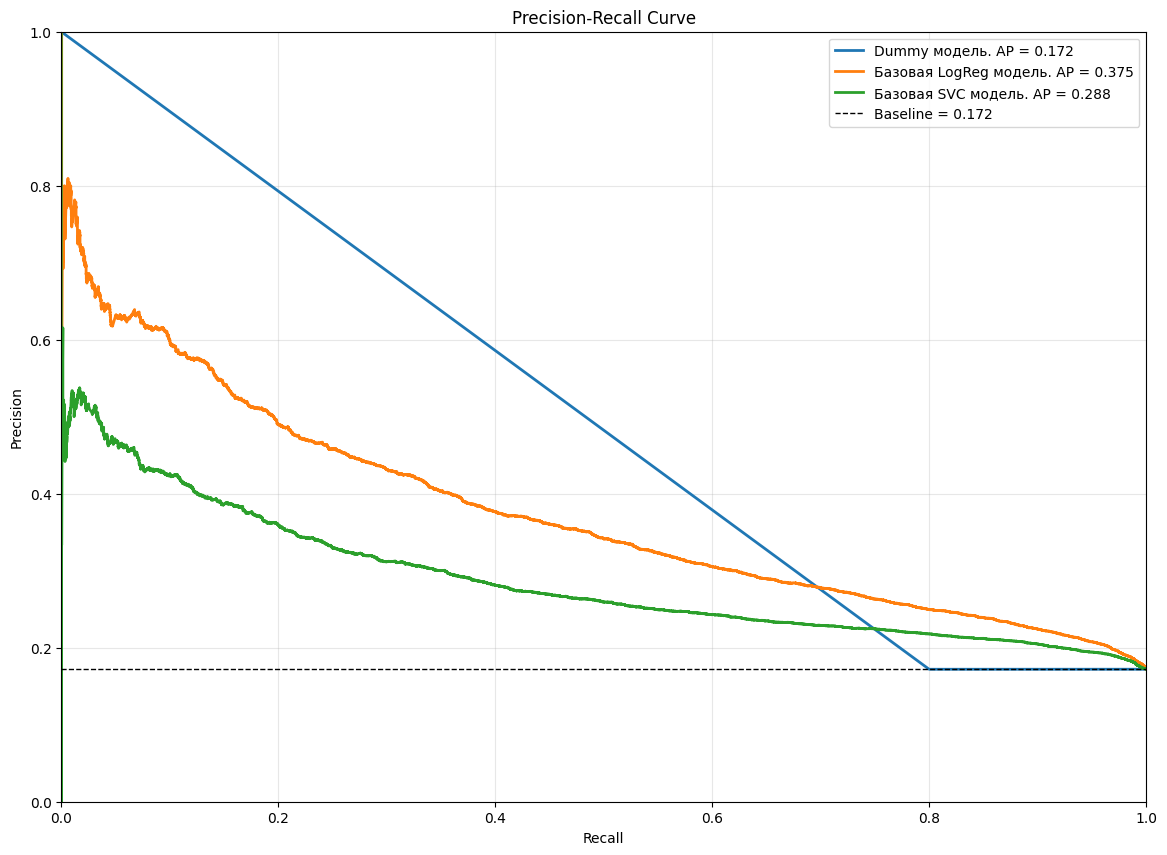

In [230]:
pr_auc_base = plot_pr_auc_curve(
    y_train, 
    [y_proba_dummy, y_proba_logreg_basic, y_proba_svc_basic], 
    labels=['Dummy модель', 'Базовая LogReg модель', 'Базовая SVC модель']
)

In [231]:
pr_auc_base

{'Dummy модель': 0.17203750454050126,
 'Базовая LogReg модель': 0.3750563035301856,
 'Базовая SVC модель': 0.2875767563592144}

Анализ:
- модели LogReg и SVC обучаются корректно, они лучше baseline по метрике average precision
- LogReg ap существенно превосходит SVC ap 

### Оценка влияния фильтрации на качество базовых моделей

- применяем фильтрацию из EDA

In [232]:
X_train_filtered = X_train.drop(columns=сols_to_drop)
X_train_filtered.info()

<class 'pandas.DataFrame'>
Index: 32000 entries, 8741 to 29644
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   site_category  32000 non-null  str    
 1   app_id         32000 non-null  str    
 2   device_type    32000 non-null  int64  
 3   C14            32000 non-null  int64  
 4   C15            32000 non-null  int64  
 5   C16            32000 non-null  int64  
 6   C18            32000 non-null  int64  
 7   C19            32000 non-null  int64  
 8   C20            17078 non-null  float64
 9   C21            32000 non-null  int64  
 10  ml_feature_5   32000 non-null  float64
 11  ml_feature_6   32000 non-null  float64
 12  ml_feature_8   32000 non-null  float64
 13  ml_feature_9   32000 non-null  float64
 14  ml_feature_10  32000 non-null  float64
dtypes: float64(6), int64(7), str(2)
memory usage: 3.9 MB


In [233]:
# обновленный пайплайн предобработки 
preprocessor_filtered = create_preprocessing_pipeline(X_train_filtered)

In [234]:
pipeline_dummy_filtered = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', dummy_model)
])
pipeline_logreg_filtered = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_basic)
])
pipeline_svc_filtered = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_basic)
])

Аналогично обучаем модели и сравниваем результаты

In [235]:
y_proba_dummy_filtered = cross_val_predict(
    pipeline_dummy_filtered, X_train_filtered, y_train, cv=kfold, method='predict_proba', verbose=1
    )[:, 1]

y_proba_logreg_basic_filtered = cross_val_predict(
    pipeline_logreg_filtered, X_train_filtered, y_train, cv=kfold, method='predict_proba', verbose=1, n_jobs=-1
)[:, 1]

y_proba_svc_basic_filtered = cross_val_predict(
    pipeline_svc_filtered, X_train_filtered, y_train, cv=kfold, method='predict_proba', verbose=1, n_jobs=-1
)[:, 1]


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   12.3s finished


Dummy модель AP: 0.17203750454050126
Базовая LogReg модель AP: 0.37212639868157077
Базовая SVC модель AP: 0.2959061564338754


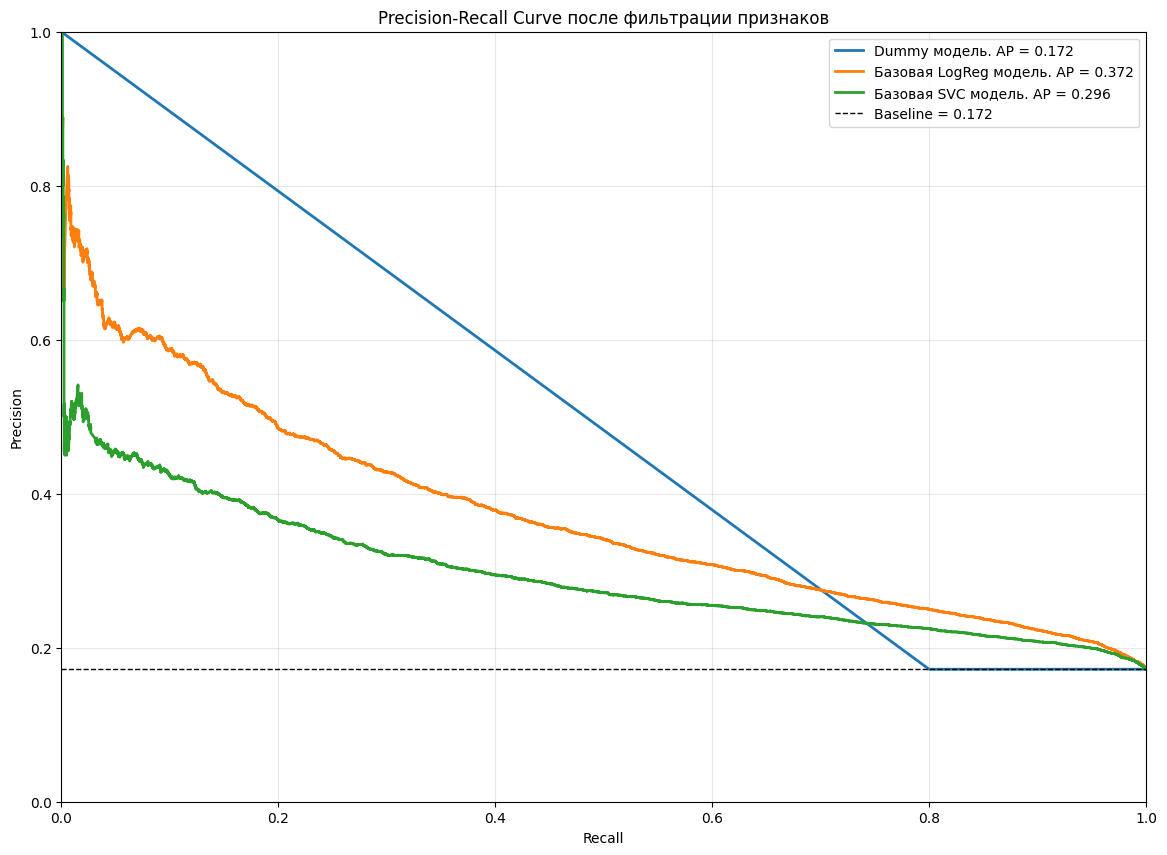

In [236]:
pr_auc_filtered = plot_pr_auc_curve(
    y_train, 
    [y_proba_dummy_filtered, y_proba_logreg_basic_filtered, y_proba_svc_basic_filtered], 
    labels=['Dummy модель', 'Базовая LogReg модель', 'Базовая SVC модель'],
    title='Precision-Recall Curve после фильтрации признаков'
)


In [237]:
pr_auc_filtered

{'Dummy модель': 0.17203750454050126,
 'Базовая LogReg модель': 0.37212639868157077,
 'Базовая SVC модель': 0.2959061564338754}

In [238]:
pr_auc_base

{'Dummy модель': 0.17203750454050126,
 'Базовая LogReg модель': 0.3750563035301856,
 'Базовая SVC модель': 0.2875767563592144}

In [239]:
# изменение метрики после фильтрации признаков
for model in pr_auc_base.keys():
    change = (pr_auc_filtered[model] - pr_auc_base[model]) / pr_auc_base[model] * 100
    print(f'{model}: изменение AP = {change:.4f} %')

Dummy модель: изменение AP = 0.0000 %
Базовая LogReg модель: изменение AP = -0.7812 %
Базовая SVC модель: изменение AP = 2.8964 %


Анализ:
- после фильтрации мало значимых признаков ключевая метрика для базовых моделей изменилась несущественно. Следовательно, данную фильтрацию имеет смысл оставить. Это повысит скорость работы и стабильность модели без существенной потере по метрикам

## 7 Отбор признаков с помощью методов-оберток
- используем метод отбора SequentialFeatureSelector

In [240]:
svm_base_model = SVC(random_state=RANDOM_SEED)
preprocessor_filtered = create_preprocessing_pipeline(X_train_filtered)

In [77]:
def get_feature_names(fitted_preprocessor):
    """Получение имен признаков"""
    feature_names = []

    for name, transformer, columns in fitted_preprocessor.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue

        if hasattr(columns, 'tolist'):
            columns = columns.tolist()

        feature_names.extend(columns)

    return np.array(feature_names)

In [78]:
def select_features(direction: str ='forward'):
    """Пайплайн для отбора признаков"""
    sfs_pipeline = Pipeline([
        ('preprocessor', preprocessor_filtered),
        ('selector', SequentialFeatureSelector(
            estimator=svm_base_model,
            n_features_to_select='auto',
            direction=direction,
            cv=3,
            scoring='roc_auc',
            n_jobs=-1,
        )),
        ('model', svm_base_model)
    ])
    sfs_pipeline.fit(X_train, y_train)
    preprocessed_feature_names = get_feature_names(sfs_pipeline.named_steps['preprocessor'])
    selected_features = preprocessed_feature_names[sfs_pipeline.named_steps['selector'].get_support()]
    return selected_features

In [79]:
# backward 
selected_feat_backward = select_features(direction='backward')
selected_feat_backward


array(['app_id', 'ml_feature_9', 'ml_feature_10', 'ml_feature_6',
       'ml_feature_8', 'C16', 'C18', 'C21'], dtype='<U13')

In [80]:
# forward
selected_feat_forward = select_features(direction='forward')
selected_feat_forward

array(['app_id', 'ml_feature_9', 'ml_feature_10', 'ml_feature_8',
       'device_type', 'C18', 'C21'], dtype='<U13')

In [81]:
essential_features = np.unique(np.concatenate([selected_feat_backward, selected_feat_forward]))
essential_features = [str(feat) for feat in essential_features if feat in X_train.columns]
essential_features

['C16',
 'C18',
 'C21',
 'app_id',
 'device_type',
 'ml_feature_10',
 'ml_feature_6',
 'ml_feature_8',
 'ml_feature_9']

Итог:
- отобранные **SequentialFeatureSelector** (backward + forward) признаки: ['C15', 'C16', 'C18', 'C21', 'ml_feature_8', 'ml_feature_9']
- рассмотрим позже обучение с этими признаками, чтобы сравнить влияние отброшенных 

## 8. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 8.1 Сетка гиперпараметров

In [82]:
# параметры кросс-валидации 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

**LogisticRegression**

Варьируем параметры:
- C - коэффициент регуляризации
- penalty - Тип регуляризации
- class_weight - учет бисбаланса классов
- max_iter - сходимость

In [83]:
logreg_basic_param_grid = [
    {
        'model__solver': ['lbfgs'],
        'model__l1_ratio': [0.0], # l2
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [1000]
    },
    {
        'model__solver': ['liblinear', 'saga'],
        'model__l1_ratio': [0.0, 1.0], # l2, l1
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [1000]
    }
]

**SVC**

In [ ]:
svc_basic_param_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10],
        'model__class_weight': ['balanced']
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [1, 10],
        'model__gamma': ['scale'],
        'model__class_weight': ['balanced']
    },
    {
        'model__kernel': ['poly'],
        'model__C': [1],
        'model__degree': [2, 3],
        'model__gamma': ['scale'],
        'model__coef0': [0],
        'model__class_weight': ['balanced']
    }
]

#### 8.2 Применение Grid Search

In [85]:
def run_model_grid_search(
    model_name: str,
    pipeline: Pipeline,
    param_grid: list[dict],
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    scoring: str = 'average_precision',
    n_jobs: int = -1,
):
    """Поиск лучших гиперпараметров с помощью GridSearchCV"""
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        return_train_score=True,
        verbose=1,
    )

    grid_search.fit(X, y)

    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    results_df = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')

    print(f'Модель: {model_name}')
    print(f'Лучшая метрика ({scoring}): {best_score:.4f}')
    print('Лучшие параметры:')
    for param_name, param_value in best_params.items():
        print(f'  {param_name}: {param_value}')

    return {
        'model_name': model_name,
        'search': grid_search,
        'best_score': best_score,
        'best_params': best_params,
        'results_df': results_df,
    }

In [86]:
logreg_basic = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
preprocessor_filtered = create_preprocessing_pipeline(X_train_filtered)

pipeline_logreg_basic = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_basic)
])

logreg_grid_result = run_model_grid_search(
    model_name='LogisticRegression',
    pipeline=pipeline_logreg_basic,
    param_grid=logreg_basic_param_grid,
    X=X_train_filtered,
    y=y_train,
    cv=cv,
)
logreg_grid_result

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Модель: LogisticRegression
Лучшая метрика (average_precision): 0.3710
Лучшие параметры:
  model__C: 1
  model__class_weight: None
  model__l1_ratio: 0.0
  model__max_iter: 1000
  model__solver: lbfgs


{'model_name': 'LogisticRegression',
 'search': GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
              estimator=Pipeline(steps=[('prep',
                                         ColumnTransformer(transformers=[('cat_target',
                                                                          Pipeline(steps=[('imputer',
                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                          ('encoder',
                                                                                           TargetEncoder())]),
                                                                          ['site_category',
                                                                           'app_id']),
                                                                         ('num_continues_norm_dist',
           

In [87]:
svc_no_probab = SVC(
    kernel='linear',
    random_state=RANDOM_SEED
)
preprocessor_filtered = create_preprocessing_pipeline(X_train_filtered)

pipeline_svc_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_no_probab)
])

svc_grid_result = run_model_grid_search(
    model_name='SVC',
    pipeline=pipeline_svc_best,
    param_grid=svc_basic_param_grid,
    X=X_train,
    y=y_train,
    cv=cv,
)
svc_grid_result

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Модель: SVC
Лучшая метрика (average_precision): 0.3692
Лучшие параметры:
  model__C: 1
  model__class_weight: balanced
  model__kernel: linear


{'model_name': 'SVC',
 'search': GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
              estimator=Pipeline(steps=[('prep',
                                         ColumnTransformer(transformers=[('cat_target',
                                                                          Pipeline(steps=[('imputer',
                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                          ('encoder',
                                                                                           TargetEncoder())]),
                                                                          ['site_category',
                                                                           'app_id']),
                                                                         ('num_continues_norm_dist',
                          

#### 8.3 Таблица результатов
- топ-10 конфигураций с их метриками.

In [88]:
def get_top_combined_grid_results(grid_results: list[dict], top_n: int = 10) -> pd.DataFrame:
    """Составление топа результатов"""
    combined_results = []

    for grid_result in grid_results:
        model_name = grid_result['model_name']
        results_df = grid_result['results_df'].copy()

        results_df['model_name'] = model_name

        results_df = results_df[
            [
                'model_name',
                'rank_test_score',
                'mean_test_score',
                'std_test_score',
                'mean_train_score',
                'std_train_score',
                'params'
            ]
        ]

        combined_results.append(results_df)

    final_df = pd.concat(combined_results, ignore_index=True)

    final_df = final_df.rename(
        columns={
            'rank_test_score': 'rank_within_model',
            'mean_test_score': 'mean_ap_test',
            'std_test_score': 'std_ap_test',
            'mean_train_score': 'mean_ap_train',
            'std_train_score': 'std_ap_train',
        }
    )

    final_df = final_df.sort_values(
        by=['mean_ap_test', 'std_ap_test'],
        ascending=[False, True]
    ).head(top_n).reset_index(drop=True)

    return final_df



In [89]:
top_logreg_models = get_top_combined_grid_results(
    grid_results=[logreg_grid_result], 
    top_n=5
)
top_logreg_models

,model_name,rank_within_model,mean_ap_test,std_ap_test,mean_ap_train,std_ap_train,params
0,LogisticRegression,1,0.371042,0.005743,0.388880,0.001796,"{'model__C': 1, 'model__class_weight': None, '..."
1,LogisticRegression,2,0.370965,0.005545,0.389004,0.001775,"{'model__C': 1, 'model__class_weight': None, '..."
2,LogisticRegression,3,0.370883,0.005648,0.388997,0.001801,"{'model__C': 1, 'model__class_weight': None, '..."
3,LogisticRegression,4,0.370467,0.005849,0.389278,0.001840,"{'model__C': 1, 'model__class_weight': 'balanc..."
4,LogisticRegression,5,0.370449,0.005956,0.388955,0.001808,"{'model__C': 1, 'model__class_weight': 'balanc..."


In [90]:
top_svc_models = get_top_combined_grid_results(
    grid_results=[svc_grid_result], 
    top_n=5
)
top_svc_models.iloc[0, :]['params']

{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}

## 8. Финальная модель

#### 8.1 Обучение финальной модели

Обучение лучших моделей: LogReg и SVC

In [91]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)  

In [130]:
def get_best_svc(
    top_svc_models: pd.DataFrame, 
    probability: bool = False, 
    random_state: int = RANDOM_SEED) -> SVC:
    best_svc_params = top_svc_models.iloc[0, :]['params']
    return SVC(
        **{k.replace('model__', ''): v for k, v in best_svc_params.items()},
        probability=probability,
        random_state=random_state
    )

In [ ]:
svc_best = get_best_svc(top_svc_models, probability=True)
svc_best

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [93]:
preprocessor_filtered = create_preprocessing_pipeline(X_train_filtered)

pipeline_svc_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', svc_best)
])

In [94]:
# обучение
pipeline_svc_best.fit(X_train_filtered, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_target', ...), ('num_continues_norm_dist', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

#### 8.2 Расчет метрик на тестовой выборке



In [95]:
def get_pr_auc_brier_score(X_test, y_test, pipeline):
    y_test_proba_svc = pipeline.predict_proba(X_test)[:, 1]
    test_pr_auc_svc = average_precision_score(y_test, y_test_proba_svc)
    test_brier_svc = brier_score_loss(y_test, y_test_proba_svc)

    svc_test_metrics = pd.DataFrame({
        'metric': ['PR-AUC', 'Brier score'],
        'value': [test_pr_auc_svc, test_brier_svc]
    })

    print(f"PR-AUC на тестовой выборке: {test_pr_auc_svc:.4f}")
    print(f"Оценка Бриера на тестовой выборке: {test_brier_svc:.4f}")
    return svc_test_metrics

обучение лучшей модели логистической регрессии

In [146]:
def get_best_logreg(
    top_logreg_models: pd.DataFrame, 
    random_state: int = RANDOM_SEED
) -> LogisticRegression:
    best_logreg_params = top_logreg_models.iloc[0, :]['params']
    return LogisticRegression(
        **{k.replace('model__', ''): v for k, v in best_logreg_params.items()},
        random_state=random_state
    )

In [147]:
logreg_best = get_best_logreg(top_logreg_models)

In [97]:
preprocessor_filtered = create_preprocessing_pipeline(X_train_filtered)

pipeline_logreg_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_best)
])


In [98]:
# обучение
pipeline_logreg_best.fit(X_train_filtered, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_target', ...), ('num_continues_norm_dist', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [99]:
X_test_filtered = X_test.drop(columns=сols_to_drop)

In [100]:
def learn_final_pipeline_with_metrics(final_pipeline, X_train, y_train, X_test, y_test):
    """Обучение финального пайплайна и расчет метрик на тестовой выборке"""
    
    # Настройка кросс-валидации
    # метрика pr-auc
    scoring = ['average_precision', 'neg_brier_score'] 
    N_FOLDS = 5
    # классы несбалансированы, применяем стратификацию
    kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)  
    # кросс-валидация для улучшенной модели на отобранном наборе признаков
    cv_results = cross_validate(
        final_pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=kfold
    )

    enhanced_means = {
        "pr_auc":cv_results["test_average_precision"].mean(),
        "brier": -cv_results["test_neg_brier_score"].mean()
    }

    # Обучение финального пайплайна 
    final_pipeline.fit(X_train, y_train)
    
    # Предсказания на тесте
    y_test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = final_pipeline.predict(X_test)
    # финальная метрика
    final_pr_auc = average_precision_score(y_test, y_test_pred_proba)
    final_brier = brier_score_loss(y_test, y_test_pred_proba)

    result = pd.DataFrame({
        'metric': ['PR-AUC', 'Brier score'],
        'cv_mean': [enhanced_means['pr_auc'], enhanced_means['brier']],
        'test_score': [final_pr_auc, final_brier],
        'difference, %': [
            round((final_pr_auc - enhanced_means['pr_auc']) / final_pr_auc * 100, 2),
            round((final_brier - enhanced_means['brier']) / final_brier * 100, 2)]
    })
    return result
    

In [101]:
logreg_result_metrics = learn_final_pipeline_with_metrics(pipeline_logreg_best, X_train_filtered, y_train, X_test_filtered, y_test)
logreg_result_metrics

,metric,cv_mean,test_score,"difference, %"
0,PR-AUC,0.373830,0.358813,-4.19
1,Brier score,0.127411,0.128931,1.18


In [102]:
svc_result_metrics = learn_final_pipeline_with_metrics(pipeline_svc_best, X_train_filtered, y_train, X_test_filtered, y_test)
svc_result_metrics

,metric,cv_mean,test_score,"difference, %"
0,PR-AUC,0.371548,0.357670,-3.88
1,Brier score,0.127608,0.129088,1.15


Анализ:
- метрики на тесте для обеих моделей проседают несущественно. Это говорит об отсутствии переобучения модели и хорошей предсказательной способности
- Logreg модель лучше по ключевым метрикам как на train, так и на test 

#### 8.3 Анализ наиболее важный признаков 
- используем веса модели, чтобы определить наиболее важные признаки

In [103]:
def get_important_features_coef_mod(pipeline):
    """
    Получение важности признаков на основе абсолютных значений коэффициентов
    """
    feature_names = get_feature_names(pipeline.named_steps['prep'])
    model = pipeline.named_steps['model']
    coefs = model.coef_[0]
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(coefs)
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    return feature_importance

In [104]:
def get_top_important_features_permutation(
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    top_n: int = 10,
    scoring: str = 'average_precision',
    n_repeats: int = 5,
    random_state: int = RANDOM_SEED,
) -> pd.DataFrame:
    """
    Топ важных признаков с помощью Permutation Importance.
    
    Функция подходит для оценки важности признаков в моделях, которые не поддерживают model.coef_
    """

    preprocessor = pipeline.named_steps['prep']
    feature_names = get_feature_names(preprocessor)

    X_transformed = preprocessor.transform(X)

    result = permutation_importance(
        pipeline.named_steps['model'],
        X_transformed,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort_values('importance_mean', ascending=False)

    return importance_df.head(top_n).reset_index(drop=True)


In [105]:
top_important_feat_logreg = get_important_features_coef_mod(
    pipeline_logreg_best, 
)
top_important_feat_logreg.head(10)

,feature,importance
0,app_id,9.397356
1,C16,3.956507
2,site_category,1.976684
3,C15,1.196754
4,ml_feature_8,0.782857
5,ml_feature_6,0.578166
6,device_type,0.532813
7,C14,0.526243
8,C20,0.524838
9,ml_feature_9,0.401869


Анализ:
- наиболее важные признаки для модели содержат: 
    - app_id - идентификатор рекламируемого мобильного приложения 
    - C16, C15 - анономные параметры баннера, пользователя, аукциона
    - site_category - категория сайта

Присутствие именно этих признаков в топе по важности в модели объясняется тем, что событие клика на рекламу главным образом связано с тем, насколько подходящий контент (app_id) подбирается для показа на заданном виде сайта (site_category). Также важную роль играют характеристики баннера, самого пользователя и аукциона.

## 9. Калибровка модели

#### 9.1 Проверка текущей калибровки

In [197]:
X_calib_filtered = X_calib.drop(columns=сols_to_drop)

In [198]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    plt.figure(figsize=(8, 8))
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [199]:
y_proba_logreg_best_filtered = cross_val_predict(
    pipeline_logreg_best, X_train_filtered, y_train, cv=kfold, method='predict_proba', verbose=0, n_jobs=-1
)[:, 1]

In [200]:
y_proba_svc_best_filtered = cross_val_predict(
    pipeline_svc_best, X_train_filtered, y_train, cv=kfold, method='predict_proba', verbose=0, n_jobs=-1
)[:, 1]


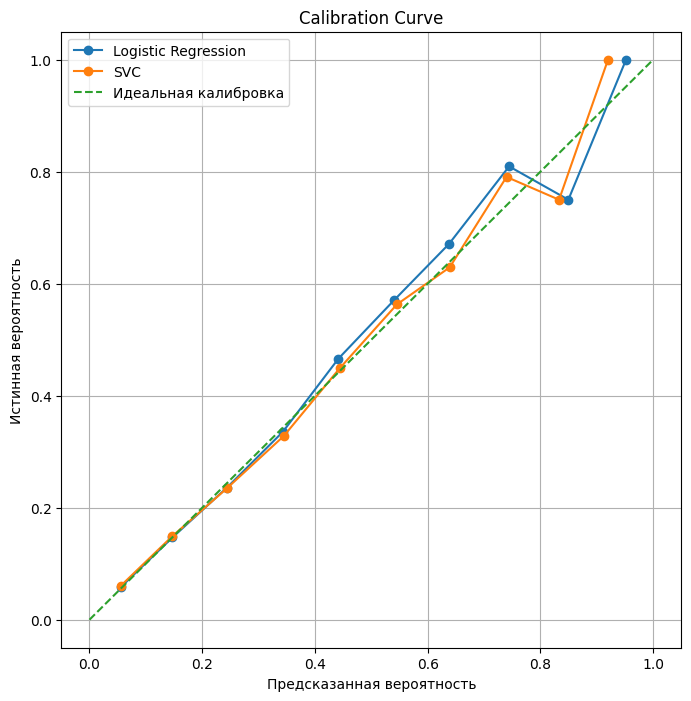

In [201]:
plot_calibration_curve(
    y_train, 
    [y_proba_logreg_best_filtered, y_proba_svc_best_filtered],
    names=['Logistic Regression', 'SVC'],
    n_bins=10
)

Анализ:
- для двух наилучших моделей необходимо провести калибровку веротяностей.
- в диапазоне 0.6-1 присутствует нарастающее по модулю различие с идеальным значением калибровки для обеих моделей

#### 9.2 Применение методов калибровки

In [202]:
def get_calibrated_model(
    model,
    X_train,
    y_train,
    X_calib,
    y_calib,
    method: str = 'isotonic',
):
    preprocessor = create_preprocessing_pipeline(X_train)
    preprocessor.fit(X_train, y_train)

    X_train_prep = preprocessor.transform(X_train)
    X_calib_prep = preprocessor.transform(X_calib)

    base_model = clone(model)
    base_model.fit(X_train_prep, y_train)

    calibrated_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(base_model),
        method=method,
    )
    calibrated_model.fit(X_calib_prep, y_calib)

    return preprocessor, base_model, calibrated_model



In [203]:
# Обучение с калибровкой 
svc_best = get_best_svc(top_svc_models, probability=True)

svc_preprocessor, svc_base, svc_calibrated = get_calibrated_model(
    model=svc_best,
    X_train=X_train_filtered,
    y_train=y_train,
    X_calib=X_calib_filtered,
    y_calib=y_calib,
    method='isotonic',
)

In [204]:
X_test_prep = svc_preprocessor.transform(X_test_filtered)

y_test_proba_svc_calibrated = svc_calibrated.predict_proba(X_test_prep)[:, 1]
y_test_proba_svc = svc_base.predict_proba(X_test_prep)[:, 1]


In [205]:
logreg_best = get_best_logreg(top_logreg_models)
logreg_preprocessor, logreg_base, logreg_calibrated = get_calibrated_model(
    model=logreg_best,
    X_train=X_train_filtered,
    y_train=y_train,
    X_calib=X_calib_filtered,
    y_calib=y_calib,
    method='isotonic',
)

In [206]:
X_test_prep = logreg_preprocessor.transform(X_test_filtered)

y_test_proba_logreg_calibrated = logreg_calibrated.predict_proba(X_test_prep)[:, 1]
y_test_proba_logreg = logreg_base.predict_proba(X_test_prep)[:, 1]

X_test_prep = logreg_preprocessor.transform(X_test_filtered)

y_test_proba_logreg_calibrated = logreg_calibrated.predict_proba(X_test_prep)[:, 1]
y_test_pred_logreg = (y_test_proba_logreg_calibrated >= 0.5).astype(int)

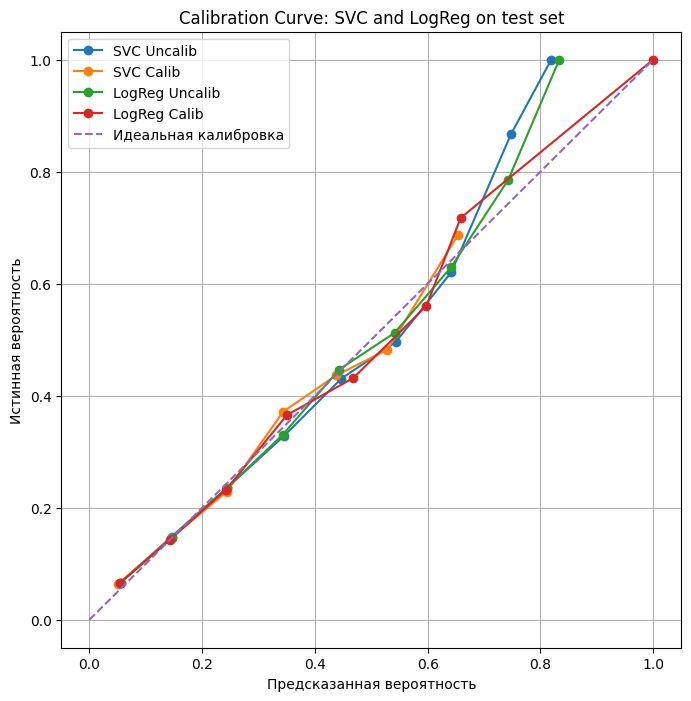

In [207]:
plot_calibration_curve(
    y_test,
    [y_test_proba_svc, y_test_proba_svc_calibrated, y_test_proba_logreg, y_test_proba_logreg_calibrated],
    names=['SVC Uncalib', 'SVC Calib', 'LogReg Uncalib', 'LogReg Calib'],
    n_bins=10,
    title='Calibration Curve: SVC and LogReg on test set'
)

## 10. Оценка качества калибровки

In [208]:
def calculate_ece(y_true, y_prob, n_bins=10):
    """Расчет ECE (Expected Calibration Error)"""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)

            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.abs(bin_conf - bin_acc) * bin_size
    return ece / n

def calculate_mce(y_true, y_prob, n_bins=10):
    """Расчет MCE (Maximum Calibration Error)"""
    bins = np.linspace(0, 1, n_bins + 1)
    max_error = 0
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            diff = np.abs(bin_conf - bin_acc)
            max_error = np.max([max_error, diff])
    return max_error


In [209]:
def get_final_metrics(y_test, model_probabilities, sort_by=['brier_score', 'ece', 'mce']):
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        ece = calculate_ece(y_test, y_proba, n_bins=10)
        mce = calculate_mce(y_test, y_proba, n_bins=10)
        pr_auc = average_precision_score(y_test, y_proba)
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_test, y_proba),
            'ece': ece,
            'mce': mce,
            'pr_auc': pr_auc
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [210]:
model_probabilities = {
    'SVC Uncalib': y_test_proba_svc,
    'SVC Calib': y_test_proba_svc_calibrated,
    'LogReg Uncalib': y_test_proba_logreg,
    'LogReg Calib': y_test_proba_logreg_calibrated
}
calibration_metrics_df = get_final_metrics(y_test, model_probabilities)
calibration_metrics_df

,model,brier_score,ece,mce,pr_auc
0,LogReg Uncalib,0.128931,0.006872,0.166457,0.358813
1,SVC Uncalib,0.129088,0.009335,0.180786,0.357670
2,LogReg Calib,0.129089,0.008769,0.058855,0.343837
3,SVC Calib,0.129137,0.010865,0.046517,0.341442


Анализ:
- калибровка моделей позволила снизисть максимальную ошибку калибровки моделей MCE. 
- оценка Бриера после процедуры калибровки немного просела для каждой модели (менее 1%)
- на ключевую метрику PR-AUC калибровка повлияла негативно: у калиброванных моделей метрика снизилась

## 11. Финальный отчёт и выводы

### 11.1 Сводная таблица результатов

In [211]:
# базовая модель
dummy_classifier = DummyClassifier(random_state=RANDOM_SEED)
pipeline_dummy = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', dummy_model)
])
pipeline_dummy.fit(X_train_filtered, y_train)

y_proba_dummy = pipeline_dummy.predict_proba(X_test_filtered)[:, 1]

In [212]:
X_test_logreg_prep = logreg_preprocessor.transform(X_test_filtered)
X_test_svc_prep = svc_preprocessor.transform(X_test_filtered)

final_model_probabilities = {
    'Dummy': pipeline_dummy.predict_proba(X_test_filtered)[:, 1],
    'LogReg Uncalib': logreg_base.predict_proba(X_test_logreg_prep)[:, 1],
    'LogReg Calib': logreg_calibrated.predict_proba(X_test_logreg_prep)[:, 1],
    'SVC Uncalib': svc_base.predict_proba(X_test_svc_prep)[:, 1],
    'SVC Calib': svc_calibrated.predict_proba(X_test_svc_prep)[:, 1],
}

result_rows = []

for name, y_proba in final_model_probabilities.items():
    result_rows.append({
        'model': name,
        'brier_score': brier_score_loss(y_test, y_proba),
        'ece': calculate_ece(y_test, y_proba, n_bins=10),
        'mce': calculate_mce(y_test, y_proba, n_bins=10),
        'pr_auc': average_precision_score(y_test, y_proba),
    })

result_df = (
    pd.DataFrame(result_rows)
    .sort_values(by='pr_auc', ascending=False)
    .reset_index(drop=True)
)

result_df


,model,brier_score,ece,mce,pr_auc
0,LogReg Uncalib,0.128931,0.006872,0.166457,0.358813
1,SVC Uncalib,0.129088,0.009335,0.180786,0.357670
2,LogReg Calib,0.129089,0.008769,0.058855,0.343837
3,SVC Calib,0.129137,0.010865,0.046517,0.341442
4,Dummy,0.142482,0.000037,0.000037,0.172100


In [242]:
pipeline_logreg_best = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', logreg_calibrated)
])

pipeline_logreg_best.fit(X_train_filtered, y_train)

top_important_feat = get_top_important_features_permutation(pipeline_logreg_best, X_train_filtered, y_train, top_n=10)
top_important_feat # топ важнейших признаков 

,feature,importance_mean,importance_std
0,app_id,0.070247,0.002909
1,ml_feature_9,0.065213,0.002364
2,ml_feature_10,0.052989,0.002857
3,C16,0.037503,0.000693
4,ml_feature_8,0.023552,0.001614
5,ml_feature_6,0.018246,0.001516
6,ml_feature_5,0.016908,0.000715
7,C14,0.009393,0.000884
8,site_category,0.007916,0.000958
9,C21,0.005976,0.001013


Анализ:


### 11.2 Выводы

Ответьте на вопросы:
- Качество разработанной модели существенно лучше baseline по ключевым метрикам: для лучшей модели LogReg метрика PR-AUC в 2 раза превосходит показатель Dummy модели. Оценка Бриера также улучшена: 0.12 < 0.14 

Признаки, влияющие больше всего на вероятность отклика:
- app_id, C16 - это характеристики рекламируемого приложения, характеристики баннера/пользователя/аукциона. Важными для модели оказались сгенерированный ML признаки: ml_feature_9,ml_feature_10, ml_feature_8  - попали в топ по значимости для итоговой модели.

Калибровка:
- модель хорошо откалибрована. В результате процедуры калибровки метрика MCE уменьшена в 3 раза

Итоговая откалиброванная модель готова к использованию в продакшене



### 11.3 Рекомендации

Среди дальнейших улучшений можно отметить генерацию новых фичей, позволяющих уследить нелинейные зависимости. Возможно, стоит в будущем поробовать более сложные нелинейные модели классификации. В настоящий момент итоговая метрика Average Precision находится на достаточно низком уровне. Линейные модели не позволяют уверенно отделить два класса друг от друга. Ядровый трюк в SVC не дал ощутимых результатов. 

## 12. Сохранение модели для продакшена

Сохранение:

In [245]:
joblib.dump(pipeline_logreg_best, 'logreg_final_pipeline.joblib')

['logreg_final_pipeline.joblib']

Проверка:

In [246]:
loaded_pipeline = joblib.load('logreg_final_pipeline.joblib')

y_pred_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
y_pred = loaded_pipeline.predict(X_test)

In [247]:
y_pred_proba

array([0.34336283, 0.25929054, 0.10590278, ..., 0.25929054, 0.12364563,
       0.21151717], shape=(10000,))